# Fig6 — Group-mean VRMSE under different surface conditions

Compute the **mean 10 m wind vector RMSE (VRMSE)** for each of the **5 weather-station groups** over the same time window as `Fig6/03_rmse_terrain_lcz.ipynb`.

- Time window (UTC, inclusive): **2025-09-23 19:00 → 2025-09-24 01:00**
- Lead time: **24h**
- Surface conditions (ERA5-only):
  - `era5_no_lcz_no_srtm` (Low terrain / Low LCZ)
  - `era5_no_lcz` (High terrain / Low LCZ)
  - `era5` (High terrain / High LCZ)

**Definition (per station)**

$$\mathrm{VRMSE} = \sqrt{\overline{(u_{sim}-u_{obs})^2 + (v_{sim}-v_{obs})^2}}$$

**Aggregation (per group)**

Mean of per-station VRMSE within each group (each station has equal weight).

In [ ]:
from __future__ import annotations

import re
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import font_manager

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------------
# Paths (inputs in ./data/wind_uv, outputs in ./publish)
# NOTE: VS Code notebooks sometimes run with CWD = workspace root.
#       The fallback below makes paths work whether CWD is Fig6/ or its parent.
# ----------------------------------------------------------------------------
FIG_DIR = Path("Fig6") if Path("Fig6").is_dir() else Path(".")
DATA_DIR = FIG_DIR / "data" / "wind_uv"
OUT_DIR = FIG_DIR / "publish"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OBS_DIR = DATA_DIR / "results_uv_obs"
SIM_DIR = DATA_DIR / "results_uv_sim"

# Additional inputs (station groups)
GROUP_MD = FIG_DIR / "data" / "20260323-材料说明.md"
_required = [OBS_DIR / "u_obs.csv", OBS_DIR / "v_obs.csv", SIM_DIR, GROUP_MD]
_missing = [p for p in _required if not p.exists()]
if _missing:
    raise FileNotFoundError(
        "Missing required input(s):\n" + "\n".join(f"- {p.as_posix()}" for p in _missing)
    )

# ----------------------------------------------------------------------------
# Configuration (match Fig6/03_rmse_terrain_lcz.ipynb)
# ----------------------------------------------------------------------------
TS_COL = "timestamp_utc"
TS_FORMAT = "%Y%m%d %H%M"  # e.g., '20250923 1900'

# Requested time window (UTC, inclusive)
START_TIME = pd.Timestamp("2025-09-23 19:00", tz="UTC")
END_TIME = pd.Timestamp("2025-09-24 01:00", tz="UTC")
WINDOW_TAG = f"{START_TIME:%Y%m%d-%H}_to_{END_TIME:%Y%m%d-%H}"

# Only 24h forecast time
LEAD = "24h"

# ERA5-driven surface-condition cases only
CASE_ORDER = [
    "era5_no_lcz_no_srtm",  # low-res terrain + low-res LCZ
    "era5_no_lcz",  # hi-res terrain + low-res LCZ
    "era5",  # hi-res terrain + hi-res LCZ
]
CASE_META: dict[str, dict[str, str]] = {
    "era5_no_lcz_no_srtm": {"label": "Low terrain\nLow LCZ", "color": "#9E9E9E"},
    "era5_no_lcz": {"label": "High terrain\nLow LCZ", "color": "#6E8BC3"},
    "era5": {"label": "High terrain\nHigh LCZ", "color": "#C96A5A"},
}

# ----------------------------------------------------------------------------
# Plot style (match Fig6/03_rmse_terrain_lcz.ipynb)
# ----------------------------------------------------------------------------
_avail_fonts = {f.name for f in font_manager.fontManager.ttflist}
FONT_FAMILY = "Arial" if "Arial" in _avail_fonts else "DejaVu Sans"

mpl.rcParams.update(
    {"font.family": FONT_FAMILY, "font.sans-serif": [FONT_FAMILY], "font.size": 16}
)

print("[Paths] DATA_DIR:", DATA_DIR.resolve())
print("[Paths] OUT_DIR :", OUT_DIR.resolve())
print("[Paths] GROUP_MD:", GROUP_MD.resolve())
print("[Config] Window:", START_TIME, "to", END_TIME, "UTC")
print("[Config] Lead  :", LEAD)
print("[Config] Cases :", ", ".join(CASE_ORDER))
print("[Font] Using   :", FONT_FAMILY)

[Paths] DATA_DIR: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\data\wind_uv
[Paths] OUT_DIR : E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\publish
[Paths] GROUP_MD: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\data\20260323-材料说明.md
[Config] Window: 2025-09-23 19:00:00+00:00 to 2025-09-24 01:00:00+00:00 UTC
[Config] Lead  : 24h
[Config] Cases : era5_no_lcz_no_srtm, era5_no_lcz, era5
[Font] Using   : Arial


In [ ]:
# ----------------------------------------------------------------------------
# Parse 5 station groups (from Fig6/data/20260323-材料说明.md)
# ----------------------------------------------------------------------------
md_text = GROUP_MD.read_text(encoding="utf-8", errors="ignore")


def parse_station_groups(md_text: str) -> dict[str, list[str]]:
    lines = md_text.splitlines()
    start_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith("## 原图4-站点分类"):
            start_idx = i
            break
    if start_idx is None:
        raise ValueError("Cannot find section '## 原图4-站点分类' in markdown.")

    end_idx = len(lines)
    for i in range(start_idx + 1, len(lines)):
        if lines[i].strip().startswith("## "):
            end_idx = i
            break

    section_lines = lines[start_idx + 1 : end_idx]
    groups: list[tuple[int, str, list[str]]] = []
    for line in section_lines:
        line = line.strip()
        # e.g. "1. 城市中心：天文台hko，中环码头cp1..."
        m = re.match(r"^(\d+)\.\s*(.+?)[：:]\s*(.+)$", line)
        if not m:
            continue
        idx = int(m.group(1))
        group_name = m.group(2).strip()
        content = m.group(3).strip().rstrip("；;。.")

        items = re.split(r"[，,、]\s*", content)
        codes: list[str] = []
        for item in items:
            item = item.strip().rstrip("；;。.")
            if not item:
                continue
            m_code = re.search(r"([A-Za-z0-9]+)\s*$", item)
            if m_code:
                codes.append(m_code.group(1).upper())
        groups.append((idx, group_name, codes))

    groups = sorted(groups, key=lambda x: x[0])
    group_dict = {name: codes for _, name, codes in groups}
    if len(group_dict) != 5:
        raise ValueError(
            f"Expected 5 groups, got {len(group_dict)}. Parsed: {list(group_dict.keys())}"
        )
    return group_dict


def group_label_en(group_name_cn: str) -> str:
    g = str(group_name_cn)
    if "城市中心" in g:
        return "Urban"
    if "内陆" in g:
        return "Plain"
    if "海边" in g:
        return "Coastal"
    if "海岛" in g:
        return "Island"
    if ("山地" in g) or ("森林" in g):
        return "Mountainous"
    return g


station_groups_cn = parse_station_groups(md_text)
group_order_cn = list(station_groups_cn.keys())
group_order_en = [group_label_en(g) for g in group_order_cn]

group_cn_to_en = {cn: group_label_en(cn) for cn in group_order_cn}
code_to_group_cn = {
    code: group_cn for group_cn, codes in station_groups_cn.items() for code in codes
}
code_to_group_en = {code: group_cn_to_en[gcn] for code, gcn in code_to_group_cn.items()}

print("Parsed station groups (CN -> EN):")
for gcn in group_order_cn:
    print(f"- {gcn} -> {group_cn_to_en[gcn]} ({len(station_groups_cn[gcn])} stations)")

group_codes_df = (
    pd.DataFrame(
        [
            {"group_cn": gcn, "group_en": group_cn_to_en[gcn], "station": code}
            for gcn in group_order_cn
            for code in station_groups_cn[gcn]
        ]
    )
    .sort_values(["group_en", "station"])
    .reset_index(drop=True)
)
display(group_codes_df)

Parsed station groups (CN -> EN):
- 城市中心 -> Urban (5 stations)
- 低矮建筑加内陆平原 -> Plain (4 stations)
- 低矮建筑加海边 -> Coastal (4 stations)
- 海岛 -> Island (6 stations)
- 山地加密集森林 -> Mountainous (4 stations)


,group_cn,group_en,station
0,低矮建筑加海边,Coastal,LFS
1,低矮建筑加海边,Coastal,SHL
2,低矮建筑加海边,Coastal,SKG
3,低矮建筑加海边,Coastal,TPK
4,海岛,Island,CCH
5,海岛,Island,GI
6,海岛,Island,PEN
7,海岛,Island,SC
8,海岛,Island,TMT
9,海岛,Island,WGL


In [ ]:
# ----------------------------------------------------------------------------
# Helpers: IO, parsing, VRMSE, saving
# ----------------------------------------------------------------------------

def save_tiff(fig: "plt.Figure", out_path: Path, dpi: int = 600) -> None:
    """Save a TIFF; tries LZW compression if supported."""
    out_path.parent.mkdir(parents=True, exist_ok=True)
    common = dict(dpi=dpi, format="tiff", bbox_inches="tight")
    try:
        fig.savefig(out_path, pil_kwargs={"compression": "tiff_lzw"}, **common)
    except TypeError:
        fig.savefig(out_path, **common)


def read_uv_obs(component: str) -> pd.DataFrame:
    path = OBS_DIR / f"{component}_obs.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing obs file: {path.as_posix()}")
    return pd.read_csv(path, dtype={TS_COL: str})


def read_uv_sim(case_key: str, component: str, lead: str) -> pd.DataFrame:
    path = SIM_DIR / f"{case_key}_{component}_sim_{lead}.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing sim file: {path.as_posix()}")
    return pd.read_csv(path, dtype={TS_COL: str})


def parse_and_subset(
    df: pd.DataFrame,
    station_cols: list[str],
    start_time: pd.Timestamp,
    end_time: pd.Timestamp,
    ts_col: str = TS_COL,
    ts_format: str = TS_FORMAT,
) -> pd.DataFrame:
    """Parse timestamps, subset to time window, and coerce station columns to numeric."""
    required_cols = [ts_col, *station_cols]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    data = df[required_cols].copy()
    data[ts_col] = data[ts_col].astype(str).str.strip()
    data[ts_col] = pd.to_datetime(data[ts_col], format=ts_format, utc=True, errors="coerce")
    data = data.dropna(subset=[ts_col])
    mask = (data[ts_col] >= start_time) & (data[ts_col] <= end_time)
    data = data.loc[mask].sort_values(ts_col).reset_index(drop=True)
    data[station_cols] = data[station_cols].apply(pd.to_numeric, errors="coerce")
    return data


def vector_rmse_by_station(
    obs_u_df: pd.DataFrame,
    obs_v_df: pd.DataFrame,
    sim_u_df: pd.DataFrame,
    sim_v_df: pd.DataFrame,
    station_cols: list[str],
    ts_col: str = TS_COL,
) -> tuple[pd.Series, int]:
    """Vector RMSE per station: sqrt(mean(du^2 + dv^2)) over common timestamps."""
    obs_u = obs_u_df[[ts_col, *station_cols]].dropna(subset=[ts_col]).set_index(ts_col)
    obs_v = obs_v_df[[ts_col, *station_cols]].dropna(subset=[ts_col]).set_index(ts_col)
    sim_u = sim_u_df[[ts_col, *station_cols]].dropna(subset=[ts_col]).set_index(ts_col)
    sim_v = sim_v_df[[ts_col, *station_cols]].dropna(subset=[ts_col]).set_index(ts_col)

    common = obs_u.index
    common = common.intersection(obs_v.index)
    common = common.intersection(sim_u.index)
    common = common.intersection(sim_v.index)
    if len(common) == 0:
        out = pd.Series(index=station_cols, dtype=float, name="vrmse")
        return out, 0

    du = sim_u.loc[common, station_cols] - obs_u.loc[common, station_cols]
    dv = sim_v.loc[common, station_cols] - obs_v.loc[common, station_cols]
    vrmse = np.sqrt((du**2 + dv**2).mean(axis=0, skipna=True))
    vrmse.name = "vrmse"
    return vrmse, int(len(common))

In [ ]:
# ----------------------------------------------------------------------------
# Load obs + sims, compute VRMSE per station, aggregate to group means
# ----------------------------------------------------------------------------
u_obs_raw = read_uv_obs("u")
v_obs_raw = read_uv_obs("v")

# Station columns from obs
obs_station_cols = [c for c in u_obs_raw.columns if c != TS_COL]

# Build case-insensitive mapping for station codes
upper_to_col: dict[str, str] = {}
duplicates: dict[str, list[str]] = {}
for c in obs_station_cols:
    key = str(c).strip().upper()
    if key in upper_to_col and upper_to_col[key] != c:
        duplicates.setdefault(key, []).extend([upper_to_col[key], c])
    upper_to_col.setdefault(key, c)
if duplicates:
    raise ValueError(
        "Duplicate station columns after uppercasing detected: "
        + ", ".join(f"{k}: {sorted(set(v))}" for k, v in duplicates.items())
    )

# Stations present in the 5 groups (codes)
group_codes_all = sorted(code_to_group_en.keys())

# Intersect with obs columns
group_codes_present = [code for code in group_codes_all if code in upper_to_col]
group_codes_missing = [code for code in group_codes_all if code not in upper_to_col]

ungrouped_obs_codes = sorted(set(upper_to_col.keys()) - set(group_codes_all))
print(f"Obs stations detected: {len(obs_station_cols)}")
print(f"Stations in groups (total codes): {len(group_codes_all)}")
print(f"Stations in groups present in obs: {len(group_codes_present)}")
if group_codes_missing:
    print("[Warning] Group station codes missing from obs columns:")
    print(group_codes_missing)
if ungrouped_obs_codes:
    print(f"[Info] Obs stations not classified into the 5 groups: {len(ungrouped_obs_codes)}")
    print(ungrouped_obs_codes)

station_cols_in_groups = [upper_to_col[code] for code in group_codes_present]
col_to_code = {upper_to_col[code]: code for code in group_codes_present}

# Sanity: obs u/v should share the same station columns
missing_in_v = sorted(set(station_cols_in_groups) - set(v_obs_raw.columns))
if missing_in_v:
    raise ValueError(f"Stations in u_obs missing from v_obs: {missing_in_v[:10]}")

# Subset observations once
obs_u = parse_and_subset(u_obs_raw, station_cols_in_groups, START_TIME, END_TIME)
obs_v = parse_and_subset(v_obs_raw, station_cols_in_groups, START_TIME, END_TIME)
print(f"Obs samples in window: u={len(obs_u)}, v={len(obs_v)}")

records_station: list[dict] = []
align_info: list[dict] = []
for case_key in CASE_ORDER:
    sim_u_raw = read_uv_sim(case_key, "u", LEAD)
    sim_v_raw = read_uv_sim(case_key, "v", LEAD)
    sim_u = parse_and_subset(sim_u_raw, station_cols_in_groups, START_TIME, END_TIME)
    sim_v = parse_and_subset(sim_v_raw, station_cols_in_groups, START_TIME, END_TIME)
    vrmse_s, n_common = vector_rmse_by_station(obs_u, obs_v, sim_u, sim_v, station_cols_in_groups)

    # Map station column -> station code
    vrmse_s = vrmse_s.rename(index=col_to_code)

    align_info.append(
        {
            "case_key": case_key,
            "case_label": CASE_META[case_key]["label"].replace("\n", " / "),
            "n_obs_u": int(len(obs_u)),
            "n_obs_v": int(len(obs_v)),
            "n_sim_u": int(len(sim_u)),
            "n_sim_v": int(len(sim_v)),
            "n_common_times": int(n_common),
            "n_stations_total_in_groups": int(len(group_codes_present)),
            "n_stations_finite": int(vrmse_s.notna().sum()),
        }
    )

    for station_code, val in vrmse_s.items():
        gcn = code_to_group_cn.get(station_code)
        gen = code_to_group_en.get(station_code)
        records_station.append(
            {
                "case_key": case_key,
                "case_label": CASE_META[case_key]["label"],
                "group_cn": gcn,
                "group_en": gen,
                "station": station_code,
                "vrmse": float(val) if pd.notna(val) else np.nan,
            }
        )

vrmse_station_long = pd.DataFrame(records_station)
align_df = pd.DataFrame(align_info)
print("\nAlignment summary:")
display(align_df)

# Aggregate: mean of per-station VRMSE within each group
tmp = vrmse_station_long.dropna(subset=["vrmse"]).copy()
vrmse_group_mean = (
    tmp.groupby(["group_en", "case_key"], as_index=False)["vrmse"]
    .agg(n_stations="count", mean_vrmse="mean")
    .copy()
)

# Apply ordering
vrmse_group_mean["__gorder"] = vrmse_group_mean["group_en"].apply(lambda x: group_order_en.index(x))
vrmse_group_mean["__corder"] = vrmse_group_mean["case_key"].apply(lambda x: CASE_ORDER.index(x))
vrmse_group_mean = vrmse_group_mean.sort_values(["__gorder", "__corder"]).drop(
    columns=["__gorder", "__corder"]
)

print("\nGroup-mean VRMSE (mean of stations):")
display(vrmse_group_mean)

# Persist numeric outputs
out_station_csv = OUT_DIR / f"vrmse_station_by_group_{WINDOW_TAG}_{LEAD}_era5_surface_cases.csv"
out_group_csv = OUT_DIR / f"vrmse_group_mean_{WINDOW_TAG}_{LEAD}_era5_surface_cases.csv"
vrmse_station_long.to_csv(out_station_csv, index=False)
vrmse_group_mean.to_csv(out_group_csv, index=False)
print("Saved:", out_station_csv.resolve())
print("Saved:", out_group_csv.resolve())

Obs stations detected: 30
Stations in groups (total codes): 23
Stations in groups present in obs: 23
[Info] Obs stations not classified into the 5 groups: 7
['HKA', 'HKS', 'JKB', 'PLC', 'SE', 'SLW', 'TME']
Obs samples in window: u=361, v=361

Alignment summary:


,case_key,case_label,n_obs_u,n_obs_v,n_sim_u,n_sim_v,n_common_times,n_stations_total_in_groups,n_stations_finite
0,era5_no_lcz_no_srtm,Low terrain / Low LCZ,361,361,361,361,361,23,23
1,era5_no_lcz,High terrain / Low LCZ,361,361,361,361,361,23,23
2,era5,High terrain / High LCZ,361,361,361,361,361,23,23



Group-mean vRMSE (mean of stations):


,group_en,case_key,n_stations,mean_vrmse
14,Urban,era5_no_lcz_no_srtm,5,25.336138
13,Urban,era5_no_lcz,5,25.133579
12,Urban,era5,5,14.551047
11,Plain,era5_no_lcz_no_srtm,4,17.326640
10,Plain,era5_no_lcz,4,18.167086
9,Plain,era5,4,11.651847
2,Coastal,era5_no_lcz_no_srtm,4,19.408107
1,Coastal,era5_no_lcz,4,20.072296
0,Coastal,era5,4,17.219624
5,Island,era5_no_lcz_no_srtm,6,25.322961


Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\publish\vrmse_station_by_group_20250923-19_to_20250924-01_24h_era5_surface_cases.csv
Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\publish\vrmse_group_mean_20250923-19_to_20250924-01_24h_era5_surface_cases.csv


Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\publish\vrmse_group_mean_20250923-19_to_20250924-01_24h_era5_surface_cases.tif


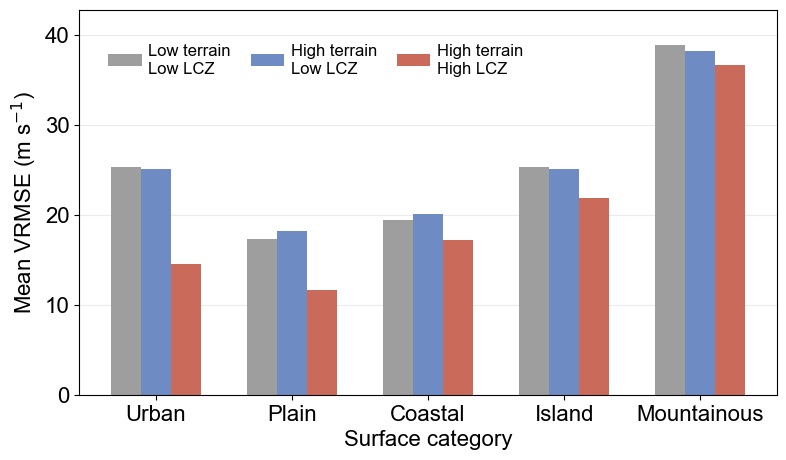

In [17]:
# ----------------------------------------------------------------------------
# Plot: x = station group, y = mean VRMSE (grouped bars by surface category)
# ----------------------------------------------------------------------------
# Build a complete grid so missing combinations show as NaN
grid = pd.MultiIndex.from_product(
    [group_order_en, CASE_ORDER], names=["group_en", "case_key"]
).to_frame(index=False)
plot_df = grid.merge(vrmse_group_mean, on=["group_en", "case_key"], how="left")

x = np.arange(len(group_order_en))
n_cases = len(CASE_ORDER)
bar_w = min(0.22, 0.85 / max(1, n_cases))

fig, ax = plt.subplots(figsize=(9.0, 5.0))
for j, case_key in enumerate(CASE_ORDER):
    sub = (
        plot_df.loc[plot_df["case_key"] == case_key]
        .set_index("group_en")
        .reindex(group_order_en)
    )
    y = sub["mean_vrmse"].to_numpy(dtype=float)
    ax.bar(
        x + (j - (n_cases - 1) / 2) * bar_w,
        y,
        width=bar_w,
        color=CASE_META[case_key]["color"],
        label=CASE_META[case_key]["label"],
        edgecolor="none",
    )

ax.set_xticks(x)
ax.set_xticklabels(group_order_en)
ax.set_xlabel("Surface category")
ax.set_ylabel("Mean VRMSE (m s$^{-1}$)")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

# Headroom so legend fits inside without covering bars
y_max = np.nanmax(plot_df["mean_vrmse"].to_numpy(dtype=float))
if np.isfinite(y_max):
    ax.set_ylim(0.0, y_max * 1.1)

# Legend inside axes: upper-left, lowered slightly; horizontal layout (single row)
ax.legend(
    frameon=False,
    ncol=n_cases,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.95),
    fontsize=12,
    columnspacing=1.2,
    handletextpad=0.4,
)

out_fig = OUT_DIR / f"vrmse_group_mean_{WINDOW_TAG}_{LEAD}_era5_surface_cases.tif"
save_tiff(fig, out_fig)
print("Saved:", out_fig.resolve())
plt.show()